# LH Nautical – Data Analysis

Autor: Luciano Brandao <> LightHouse Indicium AI

Este notebook apresenta a análise da LH Nautical com o objetivo de
organizar dados, gerar insights de negócio e propor modelos preditivos. Os datasets disponibilizados pela companhia, incluem dados sobre vendas, produtos, clientes e custos. A abordagem a seguir descreve a sequência lógica Exploração incial de dados, limpeza e tratamento, análise e recomendações.

## 1. Exploração Inicial (EDA)
Objetivo: entender a estrutura, distribuição e qualidade dos dados de vendas antes de qualquer tratamento. Utilizei RDBMS Mysql e Dbeaver. 

In [ ]:
%sql
-- EDA em SQL
-- Dataset: vendas_2023_2024.csv

SELECT COUNT(*) AS total_colunas       -- quantidade total de colunas
FROM information_schema.columns
WHERE table_schema = 'lh_nautical_db'
  AND table_name = 'vendas_2023_2024';

SELECT
    COUNT(*) AS total_linhas,          -- quantidade total de linhas
    MIN(sale_date) AS data_min,        -- data mínima
    MAX(sale_date) AS data_max,        -- data máxima
    MIN(total) AS valor_min,           -- valor mínimo
    MAX(total) AS valor_max,           -- valor máximo
    AVG(total) AS valor_medio          -- valor médio
FROM lh_nautical_db.vendas_2023_2024;

### Parte 1 — Visão geral do dataset Vendas
Objetivo: entender o volume e o período dos dados disponíveis. 
- Quantidade total de linhas: 9895  
- Quantidade total de colunas: 6  
- Intervalo de datas: de 01-01-2023 até 31-12-2024  

### Parte 2 — Análise da coluna total

Objetivo: entender a distribuição básica dos valores de vendas.

- Valor mínimo: 294.5  
- Valor máximo: 2222973.0  
- Valor médio: 263797.8  

### Parte 3 — Interpretação 

O dataset apresenta boa estrutura inicial, com volume relevante de dados e período consistente de análise.

Observa-se grande variação nos valores de venda, com presença de possíveis outliers, o que pode impactar análises futuras.  Não foram identificados valores nulos. A coluna de datas apresenta formatos inconsistentes, o que pode gerar falhas na interpretação e análise temporal dos dados.  De forma geral, o dataset é promissor, mais ainda exige tratamento prévio antes de análises mais avançadas. 

## 2. Limpeza e Tratamento de Dados



#### Etapa 1 — Padronização de categorias produtos em: eletrônicos, propulsão e ancoragem

In [13]:
import pandas as pd

df_prod = pd.read_csv("../01_data/raw/produtos_raw.csv")

df_prod['actual_category'].value_counts()

actual_category
AncorageM                9
Propução                 8
Ancoraguem               8
Eletronicoz              7
eletrônicos              7
ELETRONICOS              6
E L E T R Ô N I C O S    6
PROPULSAO                6
P R O P U L S Ã O        6
propulsão                6
Eletrunicos              5
eLeTrÔnIcOs              5
Propulção                5
Prop                     5
Propulssão               5
Encoragem                5
Ancorajm                 5
A N C O R A G E M        5
aNcOrAgEm                5
Eletrônicos              4
propulsao                4
eletronicos              3
EletrônicoS              3
Propulçao                3
Ancoragem                3
Ancorajem                3
Eletroniscos             2
Eletronicos              2
pRoPuLsÃo                2
Propulsam                2
AnCoRaGeM                2
ancoragem                2
Ancorajen                2
ELEtRÔNICOS              1
PrOpUlSãO                1
ANCORAGEM                1
Encoragi    

In [14]:
def padronizar_categoria(cat):
    cat = str(cat).lower().replace(" ", "").strip()
    
    if 'eletr' in cat:
        return 'eletrônicos'
    elif 'prop' in cat:   
        return 'propulsão'
    elif 'ancor' in cat or 'encor' in cat:
        return 'ancoragem'
    else:
        return cat

df_prod['actual_category'] = df_prod['actual_category'].apply(padronizar_categoria)

In [17]:
df_prod['actual_category'].value_counts()

actual_category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64

#### Etapa 2 — Conversão valores em produtos para tipo numérico

In [18]:
df_prod['price'] = (
    df_prod['price']
    .str.replace('R$', '', regex=False)
    .str.strip()
    .astype(float)
)

In [19]:
df_prod.dtypes

name                   str
price              float64
code                 int64
actual_category        str
dtype: object

#### Etapa 3 — Remoção de duplicatas

In [42]:
# Duplicatas
num_antes = df_prod.shape[0]

df_prod = df_prod.drop_duplicates()

num_depois = df_prod.shape[0]

duplicados_removidos = num_antes - num_depois

print(duplicados_removidos)

7


In [21]:
df_prod.to_csv("../01_data/processed/produtos_tratados.csv", index=False)

### Etapa 4 - Tratamento Custos_Importação: normalização JSON p CSV e formatação datas  

In [15]:
# Carregar JSON
df = pd.read_json("../01_data/raw/custos_importacao.json")

# Explodir lista
df = df.explode("historic_data")

# Expandir JSON aninhado
df_hist = pd.json_normalize(df["historic_data"])
df_hist['start_date'] = pd.to_datetime(
    df_hist['start_date'],
    format='%d/%m/%Y',
    errors='coerce')
df_hist['start_date'] = df_hist['start_date'].dt.strftime('%Y-%m-%d')

# Juntar tudo
df_final = pd.concat(
    [
        df[["product_id", "product_name", "category"]].reset_index(drop=True),
        df_hist.reset_index(drop=True)
    ],
    axis=1
)

# Salvar CSV
df_final.to_csv("../01_data/processed/custos_importacao_tratado.csv", index=False)

# Validação
print(len(df_final))

1260


## 3. Análise de Vendas

Foi realizada a integração entre dados de vendas, custos de importação e taxa de câmbio, considerando o id da venda, do produto e a dependência temporal. O objetivo é identificar prejuízos na venda de produtos devido ao descasamento entre valor de importação, variação cambial vs. o valor da venda. Com esta informação será possivel identificar produtos com maior impacto financeiro negativo e refletir sobre uma nova política de preços que mantenha as margens positivas frente ao custo de reposição e câmbio.

Para análise do custo em BRL de cada transação foram consideradas as seguintes premissas:
- custo unitário em USD da importação para cenários custo de estoque médio e LIFO.
- taxa de câmbio PTAX no dia da venda ou dia útil anterior para vendas em finais de semana ou feriados.
- Custos de impostos e frete foram desconsiderados conforme instrução.

O prejuízo foi identificado quando o custo total superou a receita da venda. Os resultados foram agregados por produto, permitindo identificar: receita total, prejuízo total, percentual de perda por id_produto. 

#### Download e Tratamento série histórica tx de câmbio
A taxa de câmbio utilizada foi a PTAX venda obtida via API no site do Banco Central e tratada para garantir consistência no formato de datas e valores numéricos. Os dados serão utilizados para conversão de custos de USD para BRL conforme a data de cada transação.

In [54]:
### Tratamento da cotação do dólar (PTAX venda)
import pandas as pd

# URL PTAX venda (Banco Central)
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2024"

# carregar direto da API
df_cambio = pd.read_json(url)

# converter tipos
df_cambio['data'] = pd.to_datetime(df_cambio['data'], format='%d/%m/%Y')
df_cambio['valor'] = df_cambio['valor'].astype(float)

# ordenar
df_cambio = df_cambio.sort_values('data')

# preencher dias sem cotação
df_cambio['valor'] = df_cambio['valor'].ffill()

# salvar
df_cambio.to_csv("../01_data/processed/cambio_tratado.csv", index=False)

df_cambio.head()

,data,valor
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


### Tratamento da Base de Vendas

Nesta etapa, a base de vendas é preparada para análise, com a padronização tipos numéricos e de datas. O objetivo é garantir consistência para integração com outras tabelas, como câmbio e custos.

In [62]:
import pandas as pd

df_vendas = pd.read_csv("../01_data/raw/vendas_2023_2024.csv")

# tratar datas
def parse_data(data):
    try:
        data = str(data)
        if data[:4].isdigit():
            return pd.to_datetime(data, format='%Y-%m-%d', errors='coerce')
        else:
            return pd.to_datetime(data, format='%d-%m-%Y', errors='coerce')
    except:
        return pd.NaT
df_vendas['sale_date'] = df_vendas['sale_date'].apply(parse_data)

# tratar números
df_vendas['total'] = pd.to_numeric(df_vendas['total'], errors='coerce')
df_vendas['qtd'] = pd.to_numeric(df_vendas['qtd'], errors='coerce')

# validação
print("Datas inválidas:", df_vendas['sale_date'].isna().sum())
print("Total linhas:", len(df_vendas))

# salvar
df_vendas.to_csv("../01_data/processed/vendas_tratadas.csv", index=False)

Datas inválidas: 0
Total linhas: 9895


#### SQL Agregação Dados e Cálculo Lucro/Prejuizo por produto
O custo em reais foi calculado utilizando o custo_importação unitário do produto em usd, na data mais próxima da venda (LIFO), multiplicado pela taxa de câmbio na data da venda. Em seguida, foram identificadas as transações com prejuízo (quando o custo superou a receita) e agregados os resultados por produto, calculando receita total, prejuízo total e percentual de perda. A mesma análise foi realizada para um cenário adicional considerando  a premissa custo de estoque médio. 

[SQL code cenário LIFO](../03_sql/q4_analise_vendas.sql)

#### Parte 2  - Análise Visual 📊 Dashboard Interativo (Tableau)

Gráfico iterativo que representa o prejuízo total por produto, considerando apenas produtos que tiveram prejuízo. 
O dashboard completo foi desenvolvido no Tableau e está disponível:

🔗 Tableau Public:
https://public.tableau.com/views/LH_Nautical/Sales_Analysis_LHNautical_ac

📁 Arquivo local (reprodutível):
[LH_Nautical.twbx](../07_dashsboard/LH_Nautical.twbx) Para abrir no Tableau Desktop (gratuito)

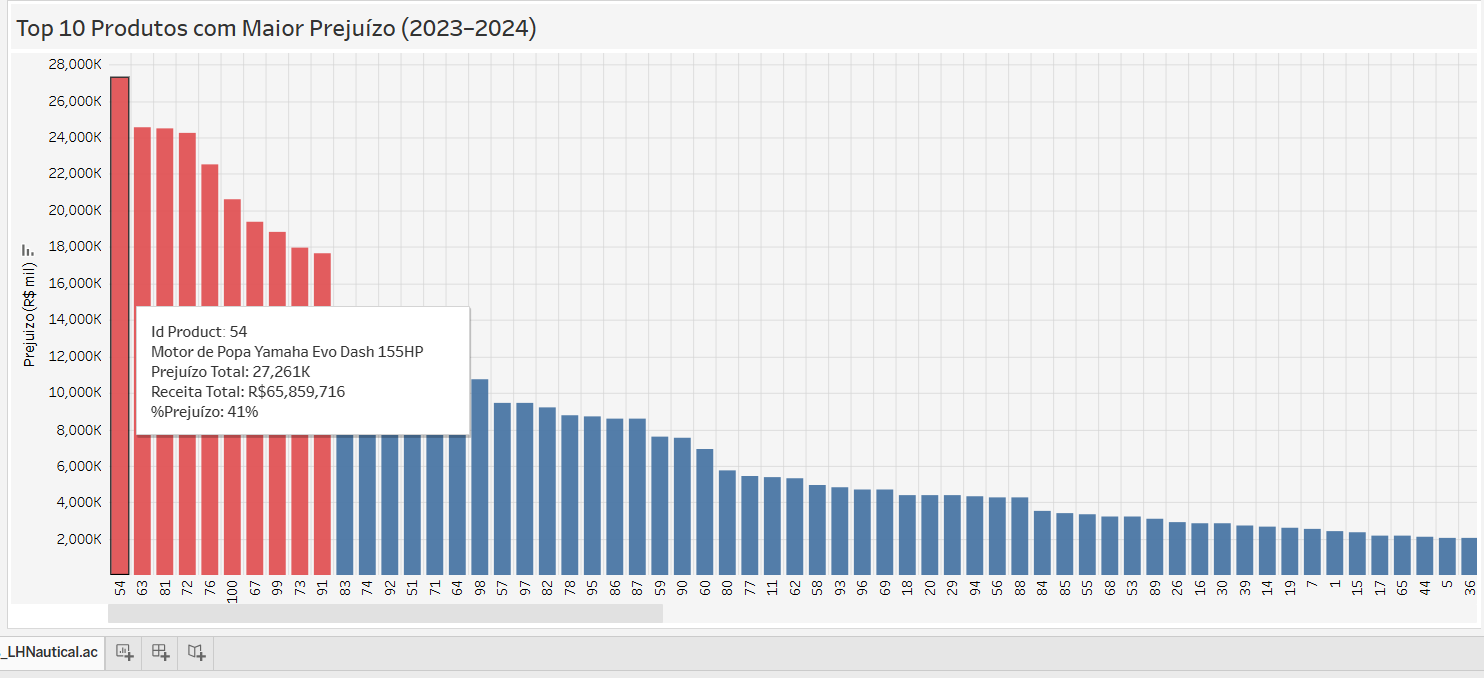

In [34]:
from IPython.display import Image

Image("../05_outputs/figures/q4.dashboard_LHNautical_Product Loss Analysis.png")


## 4. Análise de Clientes

Nesta estapa faremos uma análise sobre os clientes mais fiéis. Diferente de quem compra muito uma única vez, o cliente fiel é o cliente que possui um gasto médio alto por transação e navega por diversas categorias da loja. O objetivo é mapear o que esses clientes de elite estão consumindo para replicar o comportamento em outros segmentos.
Para esta análise faremos uma integração entre a base de dados de vendas, produtos e clientes, considerando o id da venda, id_produtos e id_clientes. 

#### Etapa 1: Tratamento e integracão bases de dados.
Realizei a integração entre as tabelas vendas_tratadas, produtos_tratados e clientes. Foi verificada a conformidade clientes_crm, e a nomenclatura de categorias de produtos_raw já havia sido tratado no item 2.1.

#### Etapa 2 : Cálculos de métricas e filtros
Após a integração das bases de dados, foram realizados cálculos e filtros para identificar as seguintes métricas e informações para cada id_cliente:
- Faturamento total por cliente
- Frequência: Contagem de transações por cliente
- Ticket médio: Faturamento médio por transação por cliente
- Diversidade de Categorias: Quantidade de categorias distintas que cada cliente comprou
- Clientes Elite: Top Clientes fiéis e que compraram produtos de 3 ou mais categorias distintas.

Com estas métricas foram realizadas as seguintes consultas: 

- Identificação dos 10 clientes "Fiéis" com maior ticket médio e que atendem ao critério diversidade, tendo realizado compras em 3 ou mais categorias de produtos.
- Identificação da categoria mais vendida (em quantidade total de itens) considerando apenas o histórico desses 10 clientes.


In [ ]:
%sql
WITH base AS (
    -- Análise de Clientes Fiéis
    -- Integração das tabelas: vendas + produtos + clientes
    SELECT
        v.id_client,
        c.full_name,
        v.id,
        v.qtd,
        v.total,
        p.actual_category
    FROM lh_nautical_db.vendas_tratadas v
    LEFT JOIN lh_nautical_db.produtos_tratados p
        ON v.id_product = p.code
    LEFT JOIN lh_nautical_db.clientes_crm c
        ON v.id_client = c.code
),

clientes_metricas AS (
    -- Cálculo das métricas por cliente: frequência, faturamento, ticket médio e diversidade
    SELECT
        id_client,
        full_name,
        COUNT(id) AS frequencia,
        SUM(total) AS faturamento_total,
        SUM(total) / COUNT(id) AS ticket_medio,
        COUNT(DISTINCT actual_category) AS diversidade
    FROM base
    GROUP BY id_client, full_name
),

top_clientes AS (
    -- Seleção dos clientes fiéis: diversidade >= 3 e maior ticket médio
    SELECT *
    FROM clientes_metricas
    WHERE diversidade >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
),

categoria_top AS (
    -- Soma da quantidade de itens por categoria considerando apenas os Top 10 clientes
    SELECT
        b.actual_category,
        SUM(b.qtd) AS total_itens
    FROM base b
    INNER JOIN top_clientes t
        ON b.id_client = t.id_client
    GROUP BY b.actual_category
)

-- Resultado final: categoria com maior volume de itens vendidos
SELECT
    actual_category,
    total_itens
FROM categoria_top
ORDER BY total_itens DESC
LIMIT 1;

#### Parte 3  - Análise Clientes Elite 📊 Dashboard Interativo (Tableau)

O Gráfico iterativo descreve o padrão de consumo, e informações detalhadas sobre as transações dos melhores clientes da LH Nautical durante os anos de 2023 a 2024.  

A análise evidencia a relação entre frequência de compras e ticket médio dos clientes Elite, definidos como aqueles com presença em mais de 3 categorias de consumo. O quadrante superior direito concentra os clientes de maior valor, combinando alta frequência e alto ticket médio, sendo estes os principais drivers de receita e candidatos prioritários para estratégias de retenção e fidelização.

Já clientes com alta frequência e ticket médio inferior indicam potencial de expansão de receita via iniciativas de aumento de ticket (upsell/cross-sell).

🔗 Tableau Public:https://public.tableau.com/views/LHNauticalEliteCustomersAnalysis/TopClients_Dashb

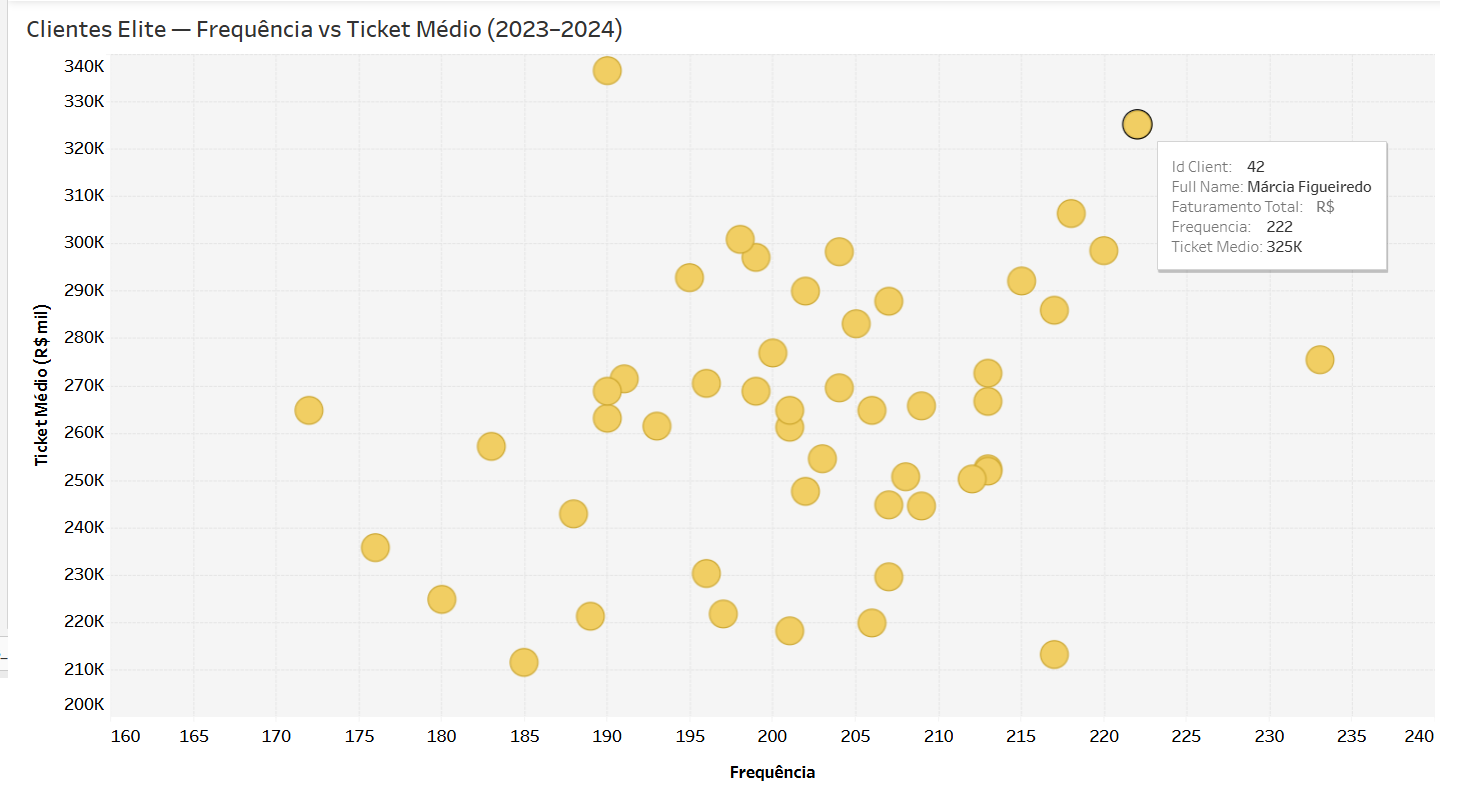

In [36]:
from IPython.display import Image

Image("../05_outputs/figures/q5.dashboard_LHNautical_Elite Customers Analysis.png")

## 5. Previsão de Demanda

## 6. Sistema de Recomendação

## 7. Insights de Negócio

## 8. Conclusão